In [1]:
import os
import timm
import torch
import numpy as np

### Get Data Loader

In [2]:
from utils.data import PlantData

data_dir = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/squared'

train_percent = 0.6
val_percent = 0.2
test_percent = 0.2

batch_size = 2

random_seed = 8

torch.manual_seed(random_seed)
np.random.seed(random_seed)


data = PlantData(data_dir, batch_size, train_percent, val_percent, test_percent, random_seed)
# data.calc_split_sizes()    

train_dataloader, val_dataloader, test_dataloader = data.get_dataloaders()
data.get_split_info(classwise=False)                    

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


 Total dataset size 	: 221
 Train dataset size 	: 132
 Val dataset size 	: 44
 Test dataset size 	: 45



### Load model file

In [3]:
timm.list_models('*convnextv2*', pretrained=True)

['convnextv2_atto.fcmae',
 'convnextv2_atto.fcmae_ft_in1k',
 'convnextv2_base.fcmae',
 'convnextv2_base.fcmae_ft_in1k',
 'convnextv2_base.fcmae_ft_in22k_in1k',
 'convnextv2_base.fcmae_ft_in22k_in1k_384',
 'convnextv2_femto.fcmae',
 'convnextv2_femto.fcmae_ft_in1k',
 'convnextv2_huge.fcmae',
 'convnextv2_huge.fcmae_ft_in1k',
 'convnextv2_huge.fcmae_ft_in22k_in1k_384',
 'convnextv2_huge.fcmae_ft_in22k_in1k_512',
 'convnextv2_large.fcmae',
 'convnextv2_large.fcmae_ft_in1k',
 'convnextv2_large.fcmae_ft_in22k_in1k',
 'convnextv2_large.fcmae_ft_in22k_in1k_384',
 'convnextv2_nano.fcmae',
 'convnextv2_nano.fcmae_ft_in1k',
 'convnextv2_nano.fcmae_ft_in22k_in1k',
 'convnextv2_nano.fcmae_ft_in22k_in1k_384',
 'convnextv2_pico.fcmae',
 'convnextv2_pico.fcmae_ft_in1k',
 'convnextv2_tiny.fcmae',
 'convnextv2_tiny.fcmae_ft_in1k',
 'convnextv2_tiny.fcmae_ft_in22k_in1k',
 'convnextv2_tiny.fcmae_ft_in22k_in1k_384']

In [4]:
timm_model_name = "convnextv2_tiny.fcmae_ft_in22k_in1k"

best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth"
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed(random_seed)
    print("GPU: ", torch.cuda.get_device_name(0))
    
model = timm.create_model(timm_model_name, pretrained=False, num_classes=21)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded from {best_model_path}")

Using device: cuda
GPU:  NVIDIA RTX A500 Laptop GPU
Model loaded from /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Evaluation

In [5]:
from utils.evaluate import EvalClassification

eval = EvalClassification(timm_model_name, best_model_path, 21, test_dataloader, data.dataset_init.classes)
eval.evaluate_accuracy()

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared
Found 9 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Ranunculus aquatilis']
Remapped 19 images to use canonical indices.
Total dataset size 	: 19
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 19

Test DataLoader created with 19 images from /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared.
Classnames 


100%|██████████| 23/23 [00:04<00:00,  5.58it/s]

Accuracy: 0.8000


0.8

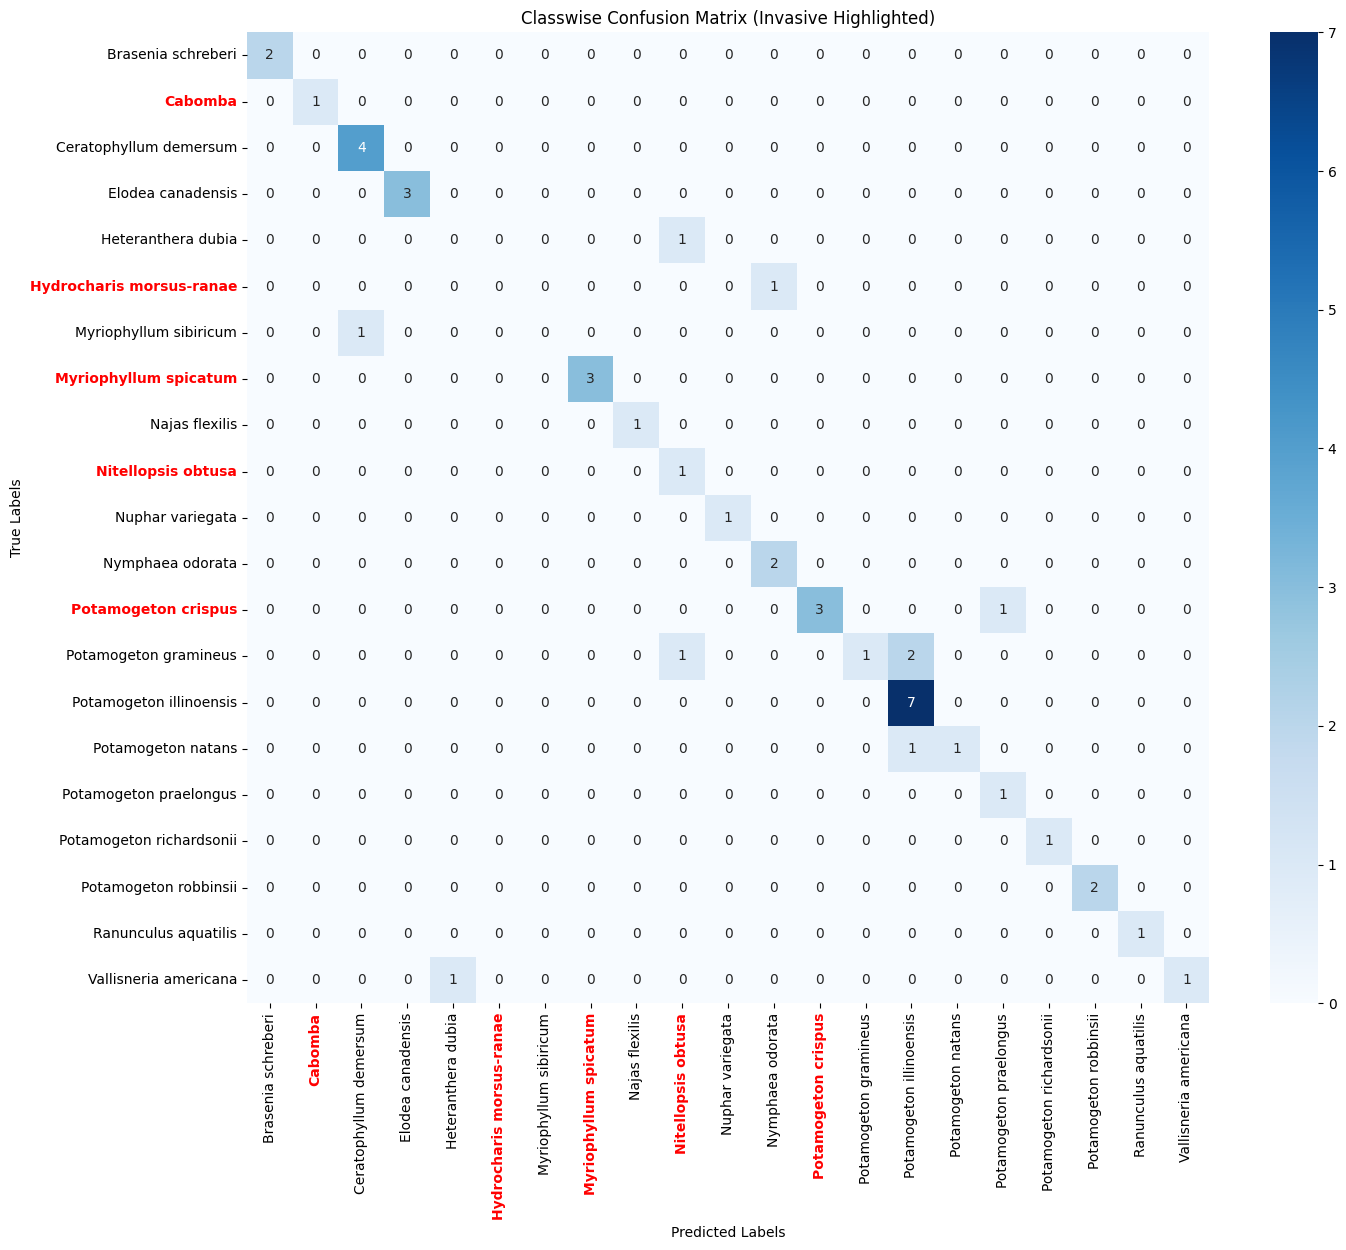


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+============+=====================+===========+
| Brasenia schreberi       |         2 |    2 |    0 |    0 |    1        |           1    |   1        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Cabomba                  |         1 |    1 |    0 |    0 |    1        |           1    |   1        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+


In [6]:
eval.get_classwise_confusion_matrix()
summary_metrics = eval.get_classwise_metrics()

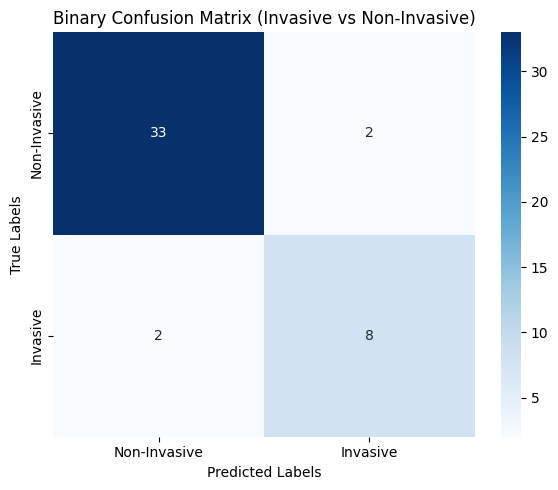


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        8 | False Positive Rate (FPR)      |    0.0571 | Negative Predictive Value (NPV) |    0.9429 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       33 | False Negative Rate (FNR)      |    0.2    | Positive " (PPV or Precision)   |    0.8    |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        2

In [7]:
eval.get_binary_confusion_matrix()
binary_matrics = eval.get_binary_metrics()

## Hand dataset

In [8]:
import utils.data as data_utils
hand_dataloader = data_utils.get_test_dataloader()
eval.change_dataloader(hand_dataloader)
eval.evaluate()
eval.get_accuracy()

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared
Found 9 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Ranunculus aquatilis']
Remapped 19 images to use canonical indices.
Total dataset size 	: 19
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 19

Test DataLoader created with 19 images from /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared.
Classnames 
Data loader updated. Please run evaluate() again to compute new predictions and true labels.


100%|██████████| 19/19 [00:02<00:00,  6.44it/s]

Accuracy: 0.3158


0.3157894736842105

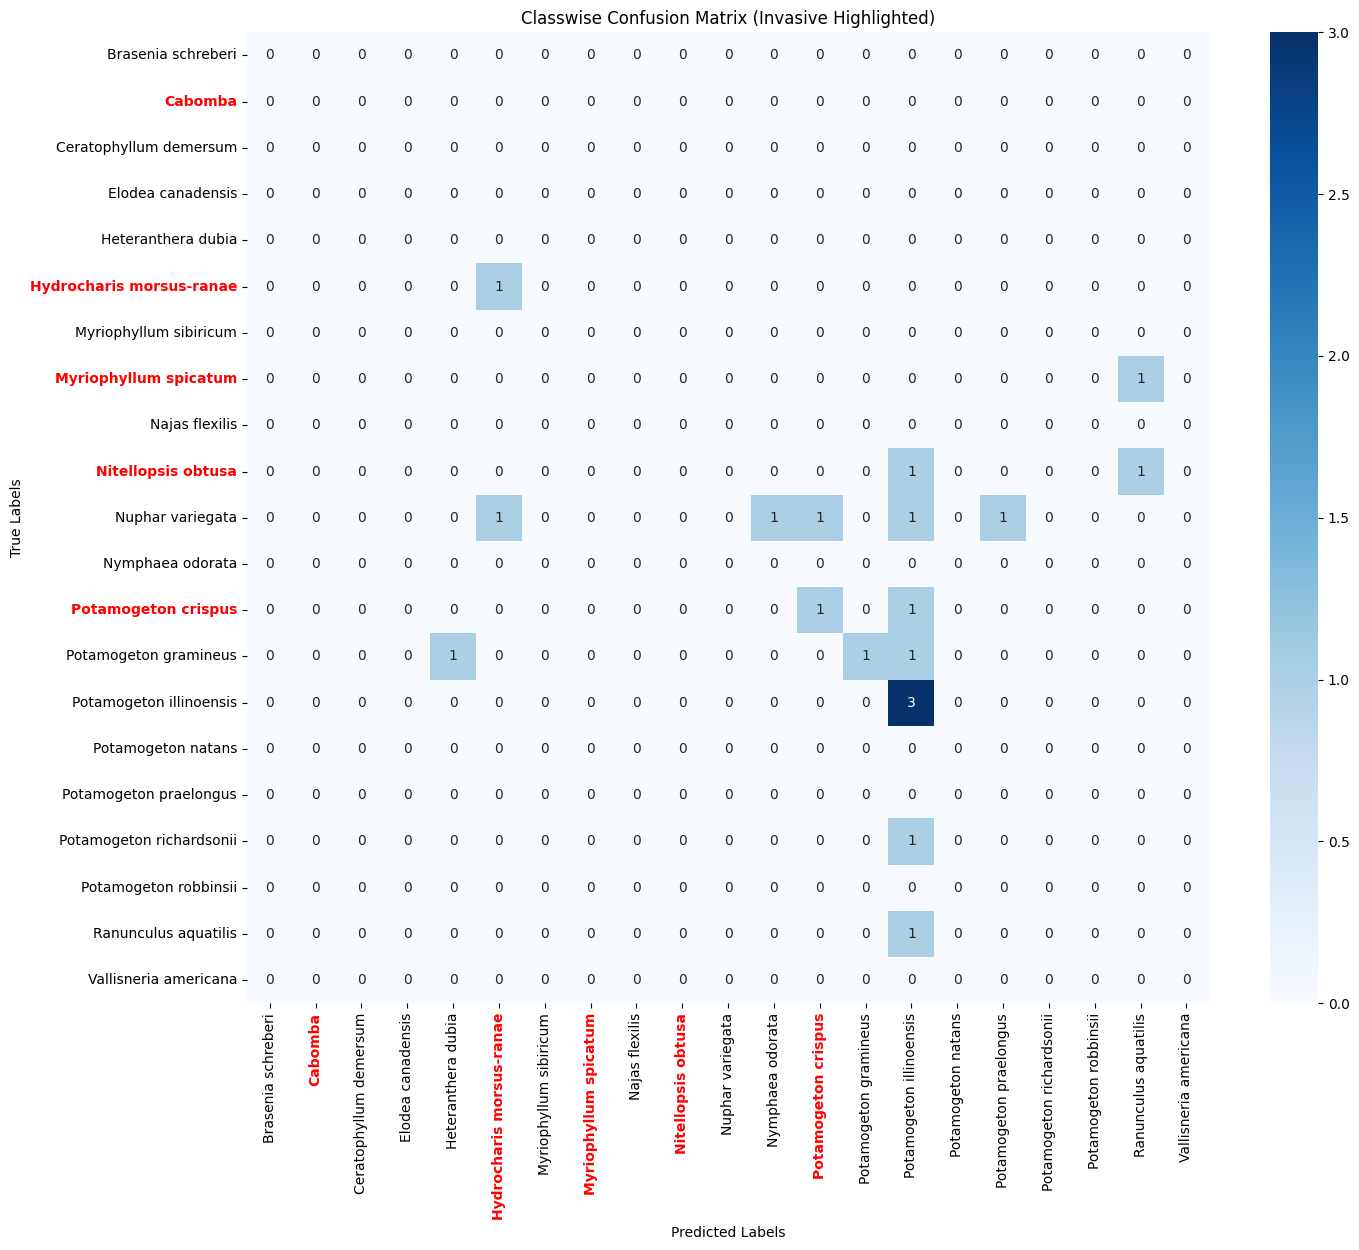

In [9]:
class_wise = eval.get_classwise_confusion_matrix()

In [10]:
metrics = eval.get_classwise_metrics()


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   F1-Score |   Specificity (TNR) |       FPR |
+==========================+===========+======+======+======+=============+================+============+=====================+===========+
| Brasenia schreberi       |         0 |    0 |    0 |    0 |    0        |       0        |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+
| Cabomba                  |         0 |    0 |    0 |    0 |    0        |       0        |   0        |            1        | 0         |
+--------------------------+-----------+------+------+------+-------------+----------------+------------+---------------------+-----------+


In [11]:
eval.print_definitions()


Definitions of Metrics:
TP:  True Positives - Invasive species correctly classified as Invasive
TN:  True Negatives - Non-Invasive species correctly classified as Non-Invasive
FP:  False Positives - Non-Invasive species incorrectly classified as Invasive
FN:  False Negatives - Invasive species incorrectly classified as Non-Invasive
FPR:  False Positive Rate - Proportion of Non-Invasive species incorrectly classified as Invasive
FNR:  False Negative Rate - Proportion of Invasive species incorrectly classified as Non-Invasive
TNR:  True Negative Rate (Specificity) - Proportion of Non-Invasive species correctly classified
TPR:  True Positive Rate (Recall or Sensitivity) - Proportion of Invasive species correctly classified
PPV:  Positive Predictive Value (Precision) - Proportion of predicted Invasive species that are actually Invasive
NPV:  Negative Predictive Value - Proportion of Non-Invasive predictions that are actually Non-Invasive
F1 Score:  Harmonic mean of Precision and Recall, b

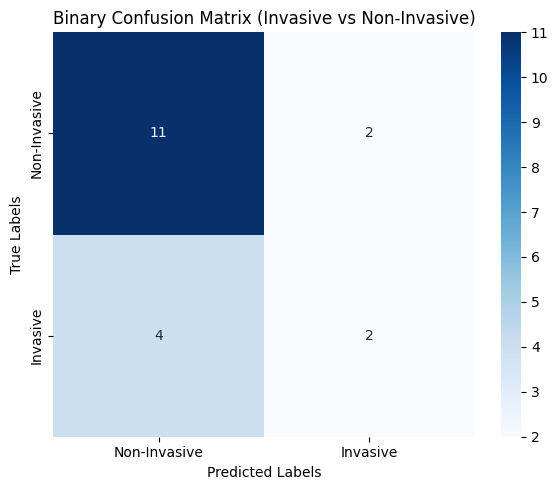

array([[11,  2],
       [ 4,  2]])

In [12]:
eval.get_binary_confusion_matrix()

In [13]:
bin_metrics = eval.get_binary_metrics()


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        2 | False Positive Rate (FPR)      |    0.1538 | Negative Predictive Value (NPV) |    0.7333 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       11 | False Negative Rate (FNR)      |    0.6667 | Positive " (PPV or Precision)   |    0.5    |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        2